# 04 — Text-feature PCA

Reduce 768-dim FinBERT stock-day embeddings (notebook 03 output) to a ranker-ready
low-dim feature set. Fit on the first walk's training window (2002-2007), pick
`n_pca` at 99% cumulative variance + 1 safety buffer, lock the dim for all
subsequent walks. Re-fit components at each walk boundary.

**Spec:** `docs/superpowers/specs/2026-05-08-text-enhanced-rl-portfolio-design.md` §5.3 / §17.2.
**Design notes** (target, +1 safety rationale, no L2-norm, no weekly resample, sanity gate) live in the module docstring of `src/utils/pca.py`.

**Mode switch:** `USE_SYNTHETIC=True` runs on planted-signal Gaussian data so the
notebook is executable end-to-end even when `data/processed/finbert_stockday_embed/`
isn't present. Flip to `False` once that directory is populated (notebook 03 output).

## A. Setup

In [ ]:
from __future__ import annotations
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

from src.utils.io import processed_dir, repo_root
from src.utils.pca import assemble_training_matrix

USE_SYNTHETIC = True  # flip to False after notebook 03 output lands

EMBED_DIR = processed_dir() / 'finbert_stockday_embed'
UNIVERSE_PATH = processed_dir() / 'universe_ids.parquet'
ARTIFACTS_DIR = repo_root() / 'artifacts' / 'pca-text'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Spec §7.2 walk-forward windows
WALK_1_START, WALK_1_END = '2002-01-01', '2007-12-31'
WALK_2_START, WALK_2_END = '2003-01-01', '2008-12-31'

TARGETS = [0.95, 0.98, 0.99]
PROD_TARGET = 0.99
SANITY_MAX_N_PCA = 200  # spec §5.3 sanity check — hard stop below

print(f'USE_SYNTHETIC={USE_SYNTHETIC}')
print(f'embed_dir={EMBED_DIR}')
print(f'walk 1 window: {WALK_1_START} -> {WALK_1_END}')
print(f'production target: {PROD_TARGET}; sensitivity: {TARGETS}')

## B. Load first-walk training matrix

Synthetic mode plants an 8-dim signal in 768-dim with ~2% Gaussian noise. The
cum-var curve should have a real elbow near 8 components; locked `n_pca` should
land at 9 (8 + 1 safety) at the 0.99 target. Real mode reads notebook 03 output
and applies the universe gate via `assemble_training_matrix`. No weekly
resample — see the `src/utils/pca.py` docstring for why.

In [ ]:
if USE_SYNTHETIC:
    rng = np.random.RandomState(42)
    # Smoke-scale, not production-scale: 5K samples is plenty to identify an 8-dim
    # signal in 768-dim and keeps the full-SVD pass under a few seconds. Real mode
    # works at ~1M+ rows x 768 (one walk's worth of daily stock-days, no resample).
    n_samples_w1 = 5_000
    n_signal = 8
    hidden = 768
    truth = rng.randn(n_samples_w1, n_signal).astype(np.float32)
    proj = rng.randn(n_signal, hidden).astype(np.float32)
    X_w1 = truth @ proj + rng.randn(n_samples_w1, hidden).astype(np.float32) * 0.02
    meta_w1 = pd.DataFrame({
        'permno': rng.choice(np.arange(10001, 10501), size=n_samples_w1),
        # Synthetic dates are decorative — PCA fit only uses X. Use random dates
        # inside walk 1 to avoid overflowing pandas ns timestamps on a long freq=B range.
        'date': pd.to_datetime('2002-01-04') + pd.to_timedelta(
            rng.randint(0, 6 * 365, size=n_samples_w1), unit='D'
        ),
    })
    print(f'synthetic walk 1: X={X_w1.shape}, samples={len(meta_w1):,}, planted_dim={n_signal}')
else:
    universe_ids = pd.read_parquet(UNIVERSE_PATH)
    X_w1, meta_w1 = assemble_training_matrix(
        embed_dir=EMBED_DIR,
        universe_ids=universe_ids,
        start=WALK_1_START,
        end=WALK_1_END,
    )
    print(f'real walk 1: X={X_w1.shape}, samples={len(meta_w1):,}')
    if len(meta_w1):
        print(f'  date range: {meta_w1.date.min().date()} -> {meta_w1.date.max().date()}')
        print(f'  unique permnos: {meta_w1.permno.nunique()}')
    # Floor is well above the locked-dim sklearn cap (~768). Real walks should
    # produce ~1M+ rows; anything under 100K means the universe gate or window
    # is misconfigured.
    assert len(meta_w1) >= 100_000, (
        f'walk 1 has {len(meta_w1)} samples; expected >= 100K. '
        'Did notebook 03 finish? Did universe_ids include enough permnos?'
    )

## C. Fit PCA on first walk; pick `n_pca`; lock

Full-rank SVD gives the §17.2 cum-var curve. Pick the smallest `n` with
`cum_var[n-1] >= target`, plus 1 safety, capped at full rank. If the resulting
`n_pca` exceeds `SANITY_MAX_N_PCA`, the elbow has blown out and this raises —
the downstream ranker assumes text reduces to a handful of dims.

In [ ]:
def _pick_n(cum_var: np.ndarray, target: float) -> int:
    """Smallest n with cum_var[n-1] >= target, +1 safety, capped at full rank."""
    if cum_var[-1] < target:
        return len(cum_var)
    n = int(np.searchsorted(cum_var, target, side='left')) + 1
    return min(n + 1, len(cum_var))


full_pca = PCA(svd_solver='full').fit(X_w1)
cum_var = np.cumsum(full_pca.explained_variance_ratio_)
n_pca = _pick_n(cum_var, target=PROD_TARGET)
pca_w1 = PCA(n_components=n_pca, svd_solver='full').fit(X_w1)
captured_at_lock = float(cum_var[n_pca - 1]) if n_pca <= len(cum_var) else 1.0
print(f'locked n_pca = {n_pca}  (target={PROD_TARGET}, includes +1 safety)')
print(f'variance captured at n_pca: {captured_at_lock:.4f}')

sensitivity = {f'{t:.2f}': int(_pick_n(cum_var, target=t)) for t in TARGETS}
print('\nsensitivity (n_pca at each target):')
for k, v in sensitivity.items():
    print(f'  target={k}: n_pca={v}')

# Spec §5.3 sanity gate — hard stop, not a warning. If real-data fit blows past
# 200 dims the ranker contract breaks; alternatives (lower target, L2-norm,
# different reducer) need a deliberate decision rather than a silent artifact.
if n_pca >= SANITY_MAX_N_PCA:
    raise AssertionError(
        f'n_pca={n_pca} >= SANITY_MAX_N_PCA={SANITY_MAX_N_PCA}. '
        'Inspect the scree; options: lower target (95 / 98), L2-normalize, or '
        'swap PCA for a small linear projection.'
    )

## D. Diagnostics — cumulative variance, scree

Cum-var on log-x to read the elbow clearly. Scree on log-y so the long noise
tail stays visible (otherwise the first eigenvalue swamps everything).


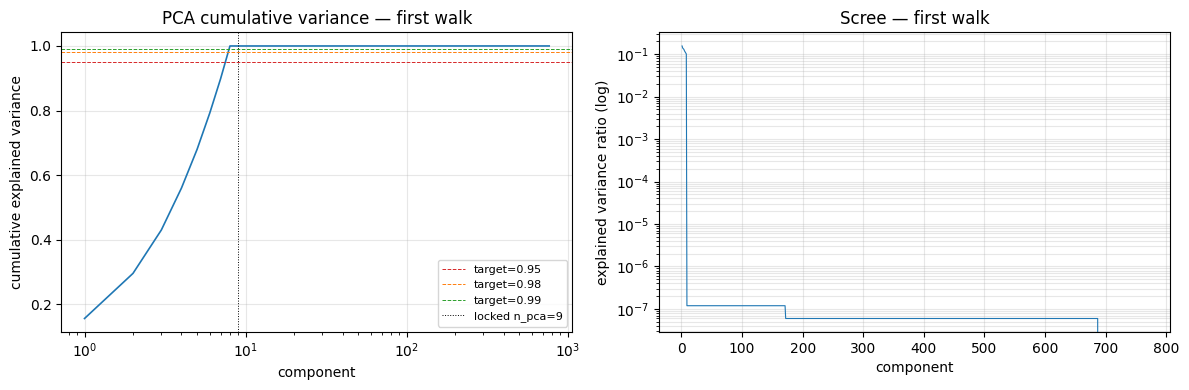

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

xs = np.arange(1, len(cum_var) + 1)
ax = axes[0]
ax.plot(xs, cum_var, lw=1.2)
for t, color in zip(TARGETS, ['tab:red', 'tab:orange', 'tab:green']):
    ax.axhline(t, color=color, ls='--', lw=0.7, label=f'target={t}')
ax.axvline(n_pca, color='black', ls=':', lw=0.7, label=f'locked n_pca={n_pca}')
ax.set_xlabel('component')
ax.set_ylabel('cumulative explained variance')
ax.set_title('PCA cumulative variance — first walk')
ax.set_xscale('log')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)

full_evr = np.diff(np.concatenate([[0.0], cum_var]))
ax = axes[1]
ax.plot(xs, full_evr, lw=0.8)
ax.set_yscale('log')
ax.set_xlabel('component')
ax.set_ylabel('explained variance ratio (log)')
ax.set_title('Scree — first walk')
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()


## E. Walk-2 re-fit demo at locked dim

Re-fit `PCA(n_components=n_pca)` on the next walk's training matrix.
`explained_variance_ratio_.sum()` per walk is the §17.2 drift sanity check —
if it falls noticeably below `PROD_TARGET` across walks, the locked dim has
become too tight (text "topic geometry" is shifting).

In [ ]:
if USE_SYNTHETIC:
    n_samples_w2 = 5_000  # smoke-scale, same as walk 1
    truth_w2 = rng.randn(n_samples_w2, n_signal).astype(np.float32)
    X_w2 = truth_w2 @ proj + rng.randn(n_samples_w2, hidden).astype(np.float32) * 0.02
else:
    X_w2, _ = assemble_training_matrix(EMBED_DIR, universe_ids, WALK_2_START, WALK_2_END)

pca_w2 = PCA(n_components=n_pca, svd_solver='full').fit(X_w2)
var_captured_w2 = float(pca_w2.explained_variance_ratio_.sum())
print(f'walk 2 fit: n_components={pca_w2.n_components_}, variance_captured={var_captured_w2:.4f}')
print(f'walk 1 captured:                                {captured_at_lock:.4f}')
print(f'drift (walk 2 minus walk 1):                    {var_captured_w2 - captured_at_lock:+.4f}')

## F. Persist artifacts

`artifacts/pca-text/walk-001/` (gitignored): fitted PCA, full cum-var curve,
summary JSON. The ranker training notebook (TBD) will load these for the
first walk's PCA transformer.


In [ ]:
WALK_1_DIR = ARTIFACTS_DIR / 'walk-001'
WALK_1_DIR.mkdir(parents=True, exist_ok=True)

# Clobber guard: refuse to overwrite a real fit with a synthetic one. The
# inverse (real overwriting synthetic) is fine and expected. Without this, a
# stray re-run in synthetic mode would silently replace the 768-dim ranker
# artifact with a 9-dim toy.
existing_summary = WALK_1_DIR / 'summary.json'
if USE_SYNTHETIC and existing_summary.exists():
    prior = json.loads(existing_summary.read_text())
    if not prior.get('use_synthetic', True):
        raise RuntimeError(
            f'refusing to overwrite real PCA artifacts at {WALK_1_DIR} with a '
            'synthetic fit. Set USE_SYNTHETIC=False or delete the walk-001 dir.'
        )

joblib.dump(pca_w1, WALK_1_DIR / 'pca.joblib')
np.save(WALK_1_DIR / 'cum_var.npy', cum_var)

summary = {
    'walk_id': 1,
    'window_start': WALK_1_START,
    'window_end': WALK_1_END,
    'target_variance': PROD_TARGET,
    'locked_n_pca': int(n_pca),
    'variance_captured_at_n_pca': captured_at_lock,
    'sensitivity_n_pca': sensitivity,
    'n_train_samples': int(X_w1.shape[0]),
    'hidden_dim': int(X_w1.shape[1]),
    'use_synthetic': USE_SYNTHETIC,
}
existing_summary.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print(f'\nartifacts -> {WALK_1_DIR.relative_to(repo_root())}')